In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("🔍 Loading data for HMM Regime Detection...")
df = pd.read_parquet('C:/Users/Sam Garcia/PycharmProjects/macro_alpha/data/processed/inference_ready_features.parquet')

# We only want the HMM to look at Price Action and Volatility, NOT macro data
# We'll use Daily Return and 20-Day Volatility
X_hmm = df[['daily_return', 'volatility_20d']].dropna()

print("🧠 Training Gaussian Hidden Markov Model...")
# We ask it to find 2 regimes (e.g., Bull vs Bear)
hmm_model = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X_hmm)

# Predict the hidden states (0 or 1)
df.loc[X_hmm.index, 'regime'] = hmm_model.predict(X_hmm)

# Let's figure out which state is which by looking at average volatility
vol_state_0 = df[df['regime'] == 0]['volatility_20d'].mean()
vol_state_1 = df[df['regime'] == 1]['volatility_20d'].mean()

if vol_state_0 > vol_state_1:
    print("State 0 is High Volatility (Bear/Crash)")
    print("State 1 is Low Volatility (Bull/Normal)")
else:
    print("State 0 is Low Volatility (Bull/Normal)")
    print("State 1 is High Volatility (Bear/Crash)")

🔍 Loading data for HMM Regime Detection...
🧠 Training Gaussian Hidden Markov Model...
State 0 is Low Volatility (Bull/Normal)
State 1 is High Volatility (Bear/Crash)


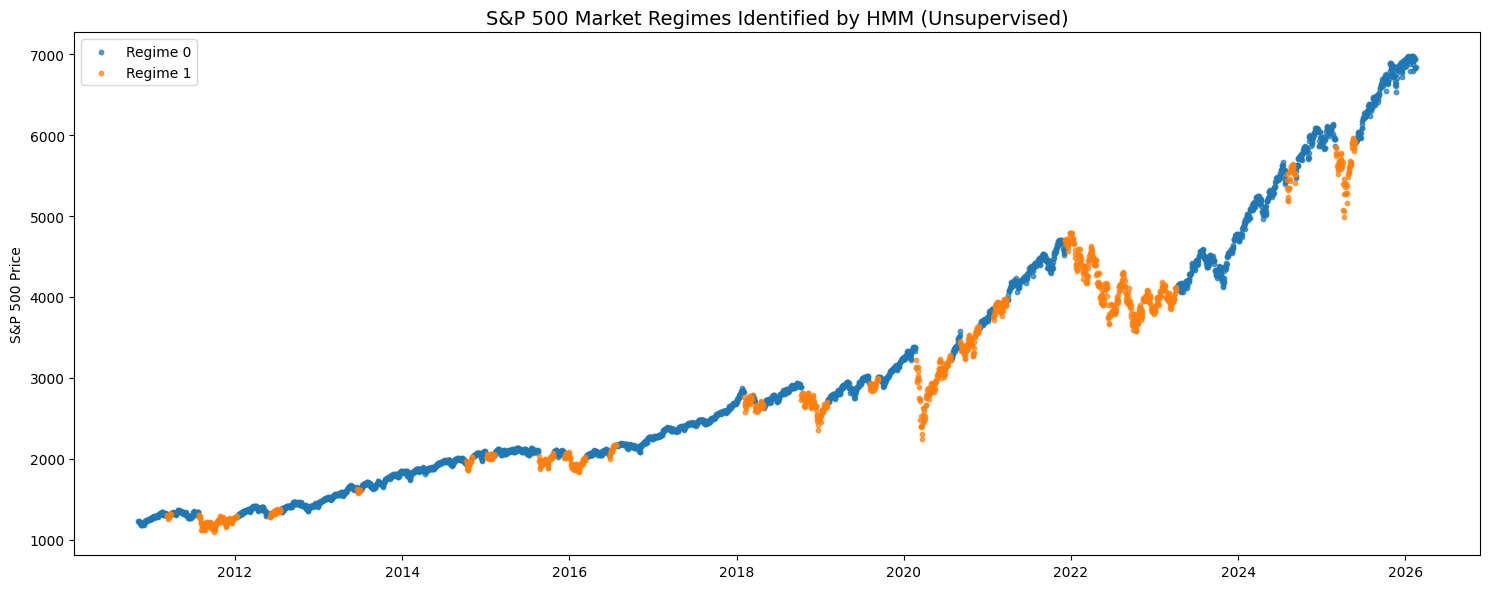

In [5]:
# 📊 Plotting the Regimes
# We will reload the raw data just to get the actual closing prices for the plot
df_raw = pd.read_parquet('C:/Users/Sam Garcia/PycharmProjects/macro_alpha/data/market_macro_data.parquet')
df['close'] = df_raw['close_sp500']

fig, ax = plt.subplots(figsize=(15, 6))

# Plot the different regimes in different colors
for i in range(2):
    state_data = df[df['regime'] == i]
    ax.scatter(state_data.index, state_data['close'], 
               label=f'Regime {i}', s=10, alpha=0.7)

ax.set_title('S&P 500 Market Regimes Identified by HMM (Unsupervised)', fontsize=14)
ax.set_ylabel('S&P 500 Price')
ax.legend()
plt.tight_layout()
plt.show()